<a href="https://colab.research.google.com/github/shantiidp/terraform/blob/main/LLM_Robustness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 LLM Robustness
## Retries · Exponential Backoff · Fallback · Hallucination Detection

---

## 🗺️ How to Use This Lab (Read This First!)

 Building the defences that keep AI systems alive and correct under real-world failure.

### What Problem Are We Solving?

In production, LLM calls **will** fail. Rate limits get hit. Servers blip. Networks time out. And even a *successful* call can return something confidently wrong. A single unhandled error can take down a customer-facing chatbot; a single hallucinated number can mislead a claims adjuster.

This lab builds the two types of robustness every GenAI engineer needs:

```
┌──────────────────────────────────────────────────────────────┐
│                Two Kinds of Robustness                       │
│                                                              │
│  OPERATIONAL ROBUSTNESS     → Keeps the service UP           │
│  Failure: exceptions — 429, 5xx, timeouts                   │
│  Fix: retries + backoff + fallback + logging                 │
│                                                              │
│  OUTPUT ROBUSTNESS          → Keeps the answers CORRECT      │
│  Failure: 200 OK but wrong — hallucination, bad numbers      │
│  Fix: grounding guards + faithfulness checks + determinism   │
└──────────────────────────────────────────────────────────────┘
```

### What You'll Build Step by Step

| Task | What You Build | Business Scenario |
|------|---------------|-------------------|
| Task 1 | Classify LLM error types | Learn which errors are worth retrying |
| Task 2 | Retry with exponential backoff | Insurance claims pipeline — 500+ claims/hour |
| Task 3 | Fallback provider (OpenAI → Groq) | Real-time banking chatbot |
| Task 4 | Production caller with logging | E-commerce review summarizer |
| Task 5 | End-to-end batch tests | Healthcare, e-commerce, insurance |
| Task 6 | Reliability metrics dashboard | Ops monitoring |
| Task 7 | Output robustness: hallucination & drift | Finance / regulated domains |

### New Concepts in This Lab

| Concept | What It Is | Why It Matters |
|---------|-----------|----------------|
| Retryable vs non-retryable errors | Classification of failure modes | Retrying a bad key wastes money; retrying a rate limit often fixes it |
| Exponential backoff | Wait 1s → 2s → 4s between retries | Prevents flooding a struggling API |
| Jitter | Random offset added to the wait | De-synchronizes retries across multiple workers |
| Fallback provider | Secondary model (Groq/Llama) if primary fails | Service stays live during OpenAI outages |
| Structured logging | Machine-readable event records with `request_id` | Enables tracing, alerting, and billing |
| Hallucination | Model inventing facts not in the source | Silent failure: 200 OK but answer is wrong |
| Grounding guard | System prompt that forces the model to admit uncertainty | Converts "usually safe" into "reliably safe" |
| `temperature=0` | Deterministic / near-zero randomness | Required for reproducible extraction tasks |

### How to Navigate

- Run cells **in order** — each task builds on the previous
- Read the **📖 What This Does** block after each code cell
- Tasks 1–3 are setup and core patterns; Tasks 4–7 are production hardening
- You need API keys for **OpenAI** and **Groq**



### Operational architecture


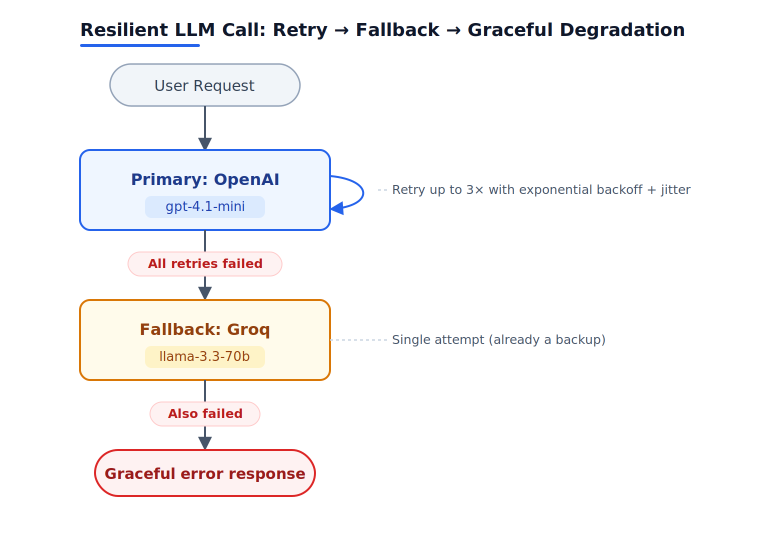

---

## Step 1 — Install the SDKs

**What are we installing?**

| Library | Purpose |
|---------|---------|
| `groq` | Official Groq SDK — lets Python call Llama 3.3 on Groq Cloud |
| `openai` | OpenAI SDK — for calling GPT models AND for its exception classes |
| `pandas` | Data analysis — used in Task 6 for the metrics dashboard |
| `python-dotenv` | Loads API keys from a `.env` file when running locally |

> 💡 **Why Groq?** Groq Cloud runs open-source models (Llama 3.3 70B) at very high speed and low cost. It is our **fallback provider** in Tasks 3 and 4 — if OpenAI fails, Groq takes over instantly.

In [ ]:
# 📦 Install all required libraries for this lab
# -q  = quiet mode (no verbose pip output)
# -U  = upgrade to latest version if already installed
# Remove the '#' from the next line to run the install
!pip install -qU groq openai pandas python-dotenv
#
# groq           → Groq Cloud SDK — runs Llama 3.3 (our fallback provider)
# openai         → OpenAI SDK — GPT models AND the exception class hierarchy
# pandas         → Data analysis — used in the reliability metrics dashboard
# python-dotenv  → Reads API keys from a .env file when running locally

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 42.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


**✅ What just happened?**
All libraries were installed (or upgraded). The `!` prefix runs a shell command inside the notebook.

> ⚠️ **If a cell fails**, try running it again. Colab occasionally has temporary network issues during installation.

---

## Step 2 — Load API Keys Securely

**What is an API key?**  
An API key is like a password that proves to OpenAI that you're an authorized user. Every time we ask the AI a question, these keys are sent along so the service knows who to charge and track.

**Where to get API keys:**

You will need an OpenAI API keys to complete this lab. If you donot have one yet, please create it by following the guides.
1. **OpenAI API Key** → [Create API Key for OpenAI](https://www.skool.com/k21academy/classroom/f1bc0b14?md=d5e61c61b5404ed7b4a1e649a270ee58)
2. **Groq API Key** → [Create API Key for Groq](https://www.skool.com/k21academy/classroom/f1bc0b14?md=06ceaa8e20694a60bcf5b124fd54a617)

Once you have created API keys, it is important to securely store them in Google Colab secrets to avoid exposing sensitive information.

 → **Follow this Activity Guide to store API keys in Google colab Secrets:** [Click Here](https://www.skool.com/k21academy/classroom/f1bc0b14?md=75d194912ba0435a98bfebdb98a1add1)

In [ ]:
import os  # Standard library — gives access to os.environ for reading/writing environment variables

def load_keys(required):
    """Load API keys from Colab Secrets (on Colab) or a local .env file (elsewhere)."""
    try:
        # Try Colab's userdata module first — only exists when running on Google Colab
        from google.colab import userdata          # running on Google Colab
        for k in required:
            try:
                # Read each key and store it as an environment variable
                # os.environ makes it available to all Python libraries in this session
                os.environ[k] = userdata.get(k)
            except Exception:
                pass                                 # key not found in Colab Secrets — skip silently
        source = "Colab Secrets"
    except ImportError:                              # ImportError = not on Colab (e.g. running locally)
        try:
            from dotenv import load_dotenv, find_dotenv
            # find_dotenv() searches the current directory and parents for a .env file
            # load_dotenv() reads it and loads key=value pairs into os.environ
            load_dotenv(find_dotenv(usecwd=True))
        except ImportError:
            pass                                     # python-dotenv not installed — skip silently
        source = ".env / environment"
    # Show where keys came from and which ones loaded successfully
    print(f"\U0001F511 Key source: {source}")
    for k in required:
        # os.environ.get(k) returns None safely if the key is missing — never raises an error
        print(f"   {k:<22} {'\u2705' if os.environ.get(k) else '\u274C MISSING'}")

# Load the two keys needed for this lab
load_keys(["OPENAI_API_KEY", "GROQ_API_KEY"])

🔑 Key source: Colab Secrets
   OPENAI_API_KEY         ✅
   GROQ_API_KEY           ✅


**✅ Expected output:**
```
🔑 Key source: Colab Secrets
   OPENAI_API_KEY         ✅
   GROQ_API_KEY           ✅
```

> ⚠️ **If you see ❌ MISSING:** Click the 🔑 icon in the Colab left sidebar → add the secret with the exact name shown (case-sensitive) → toggle **Notebook access** ON → re-run this cell.

---

## Step 3 — Initialize Clients and Imports

**Why do we import `openai` the module (not just the client)?**

The `openai` module contains the **exception class hierarchy** — `openai.RateLimitError`, `openai.AuthenticationError`, etc. We need these to classify failures in the retry logic. Importing just `from openai import OpenAI` would miss them.

**What are we importing from `time` and `random`?**
- `time.time()` — measures latency (seconds elapsed per API call)
- `time.sleep()` — pauses execution during retry backoff
- `random.uniform()` — adds jitter to backoff so concurrent workers don't all retry at the same instant

In [ ]:
import time      # Standard library — time.time() for latency, time.sleep() for backoff waits
import random    # Standard library — random.uniform() adds jitter to retry delays
import logging   # Standard library — structured logging for production observability
from datetime import datetime  # Used to timestamp log entries

import openai                      # Import the FULL module — needed for its exception classes (e.g. openai.RateLimitError)
from openai import OpenAI          # The OpenAI client class
from groq import Groq              # The Groq client class (our fallback provider)

# Initialize one client per provider
# OpenAI() automatically reads OPENAI_API_KEY from os.environ (set in Step 2)
openai_client = OpenAI()
# Groq() automatically reads GROQ_API_KEY from os.environ
groq_client   = Groq()

print("Clients initialized:", "OpenAI + Groq")

Clients initialized: OpenAI + Groq


**✅ Expected output:** `Clients initialized: OpenAI + Groq`

If you see an import error for `groq`, the pip install in Step 1 may not have run — go back and run that cell first.

---

## Task 1 — Understand the Failure Modes

**Before writing retry logic, you must know what can go wrong.**

LLM API failures fall into two categories:

| Category | When to retry? | Examples |
|----------|---------------|---------|
| **Transient (retryable)** | ✅ Yes — the error is temporary | Rate limit (429), server blip (500/503), timeout, network drop |
| **Permanent (non-retryable)** | ❌ No — retrying wastes time | Bad key (401/403), malformed request (400), wrong model name (404) |

**The key design decision:** classifying errors correctly. A retry strategy that retries a bad key 3× before failing doesn't fix anything — it just adds 10 seconds of delay. A strategy that doesn't retry a rate limit will throw away a request that would succeed 1 second later.

### Full error taxonomy for the OpenAI SDK

| Exception class | HTTP code | Cause | Retryable? |
|---|---|---|:---:|
| `openai.RateLimitError` | 429 | Too many requests per minute | ✅ |
| `openai.InternalServerError` | 500/502/503 | Provider infrastructure blip | ✅ |
| `openai.APITimeoutError` | 408 / SDK | Slow response or network | ✅ |
| `openai.APIConnectionError` | — | Network connectivity problem | ✅ |
| `openai.AuthenticationError` | 401/403 | Invalid or expired API key | ❌ |
| `openai.BadRequestError` | 400 | Malformed input / over context | ❌ |
| `openai.NotFoundError` | 404 | Wrong model name | ❌ |

Let's trigger a few of these to see the exception classes in action.

In [ ]:
# ── TEST 1: Invalid API key ──────────────────────────────────────────────────
# Expected exception: openai.AuthenticationError (HTTP 401)
# This is NON-RETRYABLE — retrying with the same bad key will always fail
print("Test 1: Invalid API key")
print("-" * 40)
try:
    # Deliberately use a fake key to trigger the auth error
    bad_client = OpenAI(api_key="sk-invalid-key-12345")
    bad_client.responses.create(model="gpt-4.1-mini", input="Hello")
except openai.AuthenticationError as e:
    # e.status_code contains the HTTP status (401 or 403)
    print(f"Caught AuthenticationError (status {e.status_code})")
    print("   -> NOT retryable. Fix the API key.")
except Exception as e:
    # Catch-all for unexpected exception types
    print(f"Caught: {type(e).__name__}: {e}")

Test 1: Invalid API key
----------------------------------------
Caught AuthenticationError (status 401)
   -> NOT retryable. Fix the API key.


**📖 What This Does:**
- Creates a deliberately broken OpenAI client with `api_key="sk-invalid-key-12345"`
- Makes an API call, which the server immediately rejects with HTTP 401
- Catches `openai.AuthenticationError` specifically (not a generic `Exception`)
- Prints the HTTP status code so you can see the raw error code

**✅ Expected output:**
```
Test 1: Invalid API key
----------------------------------------
Caught AuthenticationError (status 401)
   -> NOT retryable. Fix the API key.
```

In [ ]:
# ── TEST 2: Invalid model name ──────────────────────────────────────────────
# Expected exception: openai.NotFoundError (HTTP 404)
# This is NON-RETRYABLE — the model string is wrong, not a temporary issue
print("Test 2: Invalid model name")
print("-" * 40)
try:
    # Use a model name that doesn't exist to trigger the 404
    openai_client.responses.create(model="gpt-nonexistent-model", input="Hello")
except openai.NotFoundError as e:
    # e.status_code contains the HTTP status (404)
    print(f"Caught NotFoundError (status {e.status_code})")
    print("   -> NOT retryable. Check the model name.")
except Exception as e:
    print(f"Caught: {type(e).__name__}: {e}")

Test 2: Invalid model name
----------------------------------------
Caught: BadRequestError: Error code: 400 - {'error': {'message': "The requested model 'gpt-nonexistent-model' does not exist.", 'type': 'invalid_request_error', 'param': 'model', 'code': 'model_not_found'}}


**📖 What This Does:**
- Passes a non-existent model string (`gpt-nonexistent-model`)
- The API returns HTTP 404 because that model doesn't exist
- We catch `openai.NotFoundError` — the right exception for a model typo

**✅ Expected output:**
```
Test 2: Invalid model name
----------------------------------------
Caught NotFoundError (status 404)
   -> NOT retryable. Check the model name.
```

In [ ]:
# ── TEST 3: Successful call (baseline) ──────────────────────────────────────
# This confirms the API connection works end-to-end before we build retry logic
# A working baseline lets you distinguish "my retry logic is broken" from "the API is broken"
print("Test 3: Successful call (baseline)")
print("-" * 40)
try:
    response = openai_client.responses.create(
        model="gpt-4.1-mini",
        input="Say 'API is working' in exactly 3 words.",
        max_output_tokens=20)          # Very low token limit — this is just a wiring check
    print("Success:", response.output_text)
except Exception as e:
    print(f"Unexpected error: {type(e).__name__}: {e}")

Test 3: Successful call (baseline)
----------------------------------------
Success: API is working.


**📖 What This Does:**
- Sends a minimal prompt with a very low `max_output_tokens=20` — keeps costs near zero
- The `response.output_text` attribute extracts the model's reply as a plain string
- If this fails, something is wrong with your key or network — fix it before proceeding

**✅ Expected output:**
```
Test 3: Successful call (baseline)
----------------------------------------
Success: API is working.
```

### 📝 Key Takeaway from Task 1

The pivotal design decision is **which errors are retryable**:
- Retrying a rate limit → usually succeeds after a short wait ✅
- Retrying a bad key → wastes time, always fails ❌
- Retrying a 500 server error → often succeeds (infrastructure blips resolve quickly) ✅

This classification becomes the foundation of all retry logic in Task 2.

---

## Task 2 — Retry with Exponential Backoff

**Business scenario — insurance claims pipeline.** An insurer pushes 500+ claims/hour through an LLM summarizer. At peak, rate limits fire constantly. The pipeline must **auto-retry without dropping claims or hammering the API**.

### Why exponential backoff?

Retrying immediately after a rate limit error just makes things worse — you're already over the rate limit, so another request right away gets rejected too. Backoff waits progressively longer:

```
Attempt 1 fails → wait ~1s
Attempt 2 fails → wait ~2s
Attempt 3 fails → wait ~4s
Attempt 4 fails → give up
```

### Why add jitter (random noise)?

Without jitter, if 100 pipeline workers all hit the rate limit at the same time, they all retry at the same second — creating a *thundering herd* that floods the API again. Adding a small random offset (0–0.5s) spreads the retries over time.

**Backoff formula:**
```python
delay = base_delay * (2 ** attempt) + random.uniform(0, jitter)
```

In [ ]:
# ── ERROR CLASSIFICATION TUPLES ─────────────────────────────────────────────
# Define retryable and non-retryable error types ONCE here.
# Reusing these tuples across functions ensures consistent classification.
# Tuples work with Python's `except` clause directly: except RETRYABLE_ERRORS as e
RETRYABLE_ERRORS = (
    openai.RateLimitError,       # 429 — too many requests/minute; backoff and retry
    openai.APITimeoutError,      # request timed out; transient network issue
    openai.InternalServerError,  # 500 — server-side blip; usually resolves quickly
    openai.APIConnectionError,   # network connectivity problem; retry after a moment
)
NON_RETRYABLE_ERRORS = (
    openai.AuthenticationError,  # 401/403 — bad or expired API key; fix the key, don't retry
    openai.BadRequestError,      # 400 — malformed input or context too long; fix the request
    openai.NotFoundError,        # 404 — model name doesn't exist; fix the string
)

def call_openai_with_retry(system_prompt, user_prompt, model="gpt-4.1-mini",
                           temperature=0.7, max_tokens=500,
                           max_retries=3, base_delay=1.0):
    """Call OpenAI's Responses API with exponential-backoff retries.

    Retries on: rate limit, timeout, server error, connection error.
    Fails fast on: auth error, bad request, not found.
    Backoff formula: delay = base_delay * (2 ** attempt) + random jitter (0-0.5s)
    """
    # attempt 0 = first try; loop runs (max_retries + 1) times total
    for attempt in range(max_retries + 1):
        try:
            start = time.time()  # Record timestamp before the call for latency measurement
            response = openai_client.responses.create(
                model=model,
                instructions=system_prompt,  # OpenAI Responses API uses 'instructions' for system prompt
                input=user_prompt,           # 'input' is the user message
                temperature=temperature,
                max_output_tokens=max_tokens)
            # Build a structured result dict — same shape regardless of how many retries it took
            return {
                "provider": "OpenAI", "model": model,
                "response": response.output_text,        # Extract text from the response object
                "latency_sec": round(time.time() - start, 2),
                "attempts": attempt + 1,                 # 1-indexed so "1" means it succeeded first try
                "status": "success",
            }
        except NON_RETRYABLE_ERRORS as e:
            # For permanent errors, fail immediately — no retries
            print(f"  ❌ Non-retryable: {type(e).__name__} — failing fast (no retries)")
            raise  # Re-raise so the caller can handle it
        except RETRYABLE_ERRORS as e:
            if attempt < max_retries:
                # Calculate backoff: doubles each attempt (1s → 2s → 4s) + small random jitter
                delay = base_delay * (2 ** attempt) + random.uniform(0, 0.5)
                print(f"  ⚠️ Attempt {attempt + 1} failed ({type(e).__name__}); "
                      f"retrying in {delay:.1f}s ({max_retries - attempt} left)")
                time.sleep(delay)  # Wait before retrying
            else:
                # All retries exhausted — give up and re-raise
                print(f"  ❌ All {max_retries + 1} attempts exhausted: {type(e).__name__}")
                raise
        except Exception as e:
            # Catch-all for truly unexpected errors (SDK bugs, etc.)
            print(f"  ❌ Unexpected: {type(e).__name__}: {e}")
            raise

print("Retry function defined.")

Retry function defined.


**📖 What This Does — Key Design Decisions:**

**Why `for attempt in range(max_retries + 1)`?**
`range(max_retries + 1)` with `max_retries=3` gives attempts 0, 1, 2, 3 — four tries total (one first try + three retries). Attempt 0 is the first try, not the first retry.

**Why two separate `except` clauses?**
Python executes the first matching `except` clause. By catching `NON_RETRYABLE_ERRORS` first, we guarantee that auth and bad-request errors are never retried. The second clause catches transient errors and applies the backoff logic.

**Why `raise` (not `return`)?**
Both `except` branches re-raise the exception after giving up. This lets the caller (`call_with_fallback` in Task 3) decide what to do next — whether to try the fallback provider or propagate the error upward.

**The result dict shape:**
Every successful call returns the same dict structure (`provider`, `model`, `response`, `latency_sec`, `attempts`, `status`) so downstream code doesn't need to know which attempt succeeded.

**✅ No output yet** — this cell defines the function. Output appears when you call it below.

In [ ]:
# ── HAPPY-PATH TEST ──────────────────────────────────────────────────────────
# Business scenario: Auto-summarize a health-insurance claim
# We expect this to succeed on the first attempt with real API keys
system = "You are an insurance claims analyst. Summarize claims concisely."
claim = """Claim #HC-2025-4412: Policyholder Meera Shah, age 45, was admitted for
emergency appendectomy at Apollo Hospital, Mumbai on Feb 3, 2025. Total bill: ₹3.2L.
Policy: Star Health Comprehensive, Sum Insured ₹10L, no sub-limits on surgery.
Pre-authorization obtained. Discharged on Feb 5. All documents submitted."""

# Call the retry function — max_tokens=200 caps the response length
result = call_openai_with_retry(system, claim, max_tokens=200)

# result["attempts"] shows how many tries it took (should be 1 on a healthy connection)
print(f"\n✅ Success in {result['attempts']} attempt(s) | {result['latency_sec']}s\n")
print(result["response"])


✅ Success in 1 attempt(s) | 3.03s

Claim #HC-2025-4412 Summary:
- Policyholder: Meera Shah, 45 years
- Treatment: Emergency appendectomy
- Hospital: Apollo Hospital, Mumbai
- Admission: Feb 3, 2025; Discharge: Feb 5, 2025
- Total bill: ₹3.2 Lakhs
- Policy: Star Health Comprehensive, Sum Insured ₹10 Lakhs, no surgery sub-limits
- Pre-authorization obtained; all documents submitted


**📖 What This Does:**
- Calls `call_openai_with_retry()` with a real insurance claim
- `max_tokens=200` limits the response to keep costs low
- `result["attempts"]` will be `1` on the first successful try

**✅ Expected output (wording will vary):**
```
✅ Success in 1 attempt(s) | 1.23s

Claim #HC-2025-4412 summary: Emergency appendectomy for 45-year-old policyholder
at Apollo Hospital, Mumbai. Total bill ₹3.2L is within the ₹10L sum insured
with no sub-limits. Pre-authorization obtained. Claim eligible for full reimbursement.
```

In [ ]:
# ── PROVE NON-RETRYABLE ERRORS FAIL FAST ─────────────────────────────────────
# This test verifies that auth errors are NOT retried — saving time and money.
# Teaching trick: temporarily swap the global openai_client for a broken one,
# then restore it in the `finally` block (always runs, even if the code raises).
print("Non-retryable error should fail immediately...")
print("-" * 60)
real_client = openai_client  # Save a reference to the real client
try:
    # Swap in a broken client — this simulates an invalid API key scenario
    globals()["openai_client"] = OpenAI(api_key="sk-broken-key")
    call_openai_with_retry("test", "test", max_retries=3)  # max_retries=3 → would wait 10+ seconds if retried
except openai.AuthenticationError:
    # This should fire immediately — no retry delay
    print("\n✅ Failed immediately — zero retries wasted on a permanent error")
except Exception as e:
    print(f"\nCaught: {type(e).__name__}")
finally:
    # ALWAYS restore the real client — even if an exception occurs
    globals()["openai_client"] = real_client
    print("Real client restored.")

Non-retryable error should fail immediately...
------------------------------------------------------------
  ❌ Non-retryable: AuthenticationError — failing fast (no retries)

✅ Failed immediately — zero retries wasted on a permanent error
Real client restored.


**📖 What This Does:**

**`globals()["openai_client"] = ...`** — This swaps the global variable `openai_client` to a broken version. Using `globals()` (instead of `openai_client = ...`) ensures the retry function inside sees the broken client, not a local copy.

**`finally` block** — Python's `finally` always runs, whether or not an exception was raised. This is the correct way to guarantee the real client is always restored.

**✅ Expected output:**
```
Non-retryable error should fail immediately...
------------------------------------------------------------
  ❌ Non-retryable: AuthenticationError — failing fast (no retries)

✅ Failed immediately — zero retries wasted on a permanent error
Real client restored.
```

### 📝 Task 2 Discussion
- **Backoff** prevents all clients from retrying on the same instant (thundering herd).
- **Jitter** de-synchronizes retries across pipeline workers.
- **Fail-fast on permanent errors** saves time and money — no point retrying a bad key 3×.

---

## Task 3 — Fallback Provider (OpenAI → Groq)

**Business scenario — real-time banking chatbot.** A bank's bot handles 10,000+ chats/day. If OpenAI is down or throttled, the bot must **not** go dark — it silently switches to Groq (Llama 3.3) so customers never notice.

### The 1-level fallback pattern

```
Customer query arrives
        │
        ▼
┌───────────────────────────────┐
│  Primary: OpenAI (gpt-4.1)   │ ← with retries (backoff up to max_retries)
│  Retry on: 429, 500, timeout  │
└───────────────────────────────┘
        │ Primary fails all retries
        ▼
┌───────────────────────────────┐
│  Fallback: Groq (Llama 3.3)  │ ← single attempt, no retries
└───────────────────────────────┘
        │ Fallback also fails
        ▼
   Return graceful error message
   (customer sees a friendly "try again later")
```

**Important:** We **do NOT fall back on non-retryable errors** (bad key, malformed request). If the request is malformed, a second provider won't help — it will also reject it.

### Why Groq as the fallback?

Groq Cloud runs open-source Llama 3.3 70B at very high speed (often faster than GPT-4.1-mini). It has a generous free tier and a different infrastructure footprint from OpenAI — so the two are unlikely to fail at the same time.

In [ ]:
# ── FALLBACK FUNCTION: Groq (Llama 3.3) ────────────────────────────────────
def call_groq_fallback(system_prompt, user_prompt, temperature=0.7, max_tokens=500):
    """Fallback provider: Groq Cloud running Llama 3.3 70B.

    Uses the standard OpenAI-compatible chat completions format.
    Groq's API mirrors OpenAI's shape — same message roles, same response structure.
    """
    start = time.time()
    # Groq uses the OpenAI-compatible chat completions endpoint
    # messages = list of role/content dicts — same format as openai.chat.completions
    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",       # Llama 3.3 70B — Groq's flagship open-source model
        messages=[{"role": "system", "content": system_prompt},
                  {"role": "user", "content": user_prompt}],
        temperature=temperature,
        max_tokens=max_tokens)
    # Return the same dict shape as call_openai_with_retry so callers don't need to branch
    return {
        "provider": "Groq (Fallback)", "model": "llama-3.3-70b-versatile",
        "response": response.choices[0].message.content,  # Groq uses .choices[0].message.content
        "latency_sec": round(time.time() - start, 2),
        "status": "success_via_fallback",
    }

# ── ORCHESTRATION FUNCTION: Primary → Fallback ───────────────────────────────
def call_with_fallback(system_prompt, user_prompt, temperature=0.7, max_tokens=500):
    """Primary (OpenAI + retries) → Fallback (Groq once) → graceful error.

    Never falls back on non-retryable errors — if the input is bad, a second
    provider won't fix it either.
    """
    try:
        print("🔵 Trying primary: OpenAI (gpt-4.1-mini)...")
        # call_openai_with_retry handles retries internally; raises on exhaustion
        result = call_openai_with_retry(system_prompt, user_prompt,
                                        temperature=temperature, max_tokens=max_tokens)
        print(f"   ✅ Primary succeeded in {result['attempts']} attempt(s)")
        return result
    except NON_RETRYABLE_ERRORS as e:
        # Auth / bad-request errors: skip fallback — it won't help either
        print(f"   ❌ Non-retryable — skipping fallback: {type(e).__name__}")
        return {"provider": "None", "model": "N/A",
                "response": f"Error: {type(e).__name__} — {str(e)[:200]}",
                "latency_sec": -1, "status": "permanent_error"}
    except Exception as primary_error:
        # Transient errors exhausted all retries — try the fallback
        print("\n🟡 Primary failed after retries. Switching to fallback: Groq (Llama 3.3)...")
        try:
            # Single attempt on the fallback — no retry loop here
            result = call_groq_fallback(system_prompt, user_prompt,
                                        temperature=temperature, max_tokens=max_tokens)
            print(f"   ✅ Fallback succeeded | {result['latency_sec']}s")
            return result
        except Exception as fallback_error:
            # Both providers failed — return a safe graceful error message
            print(f"   ❌ Fallback also failed: {type(fallback_error).__name__}")
            return {"provider": "None", "model": "N/A",
                    # Customer-facing message — never expose raw error details
                    "response": "Service temporarily unavailable. Please try again later.",
                    "latency_sec": -1, "status": "all_providers_failed",
                    "primary_error": str(primary_error)[:200],
                    "fallback_error": str(fallback_error)[:200]}

print("Fallback functions defined.")

Fallback functions defined.


**📖 What This Does — Key Design Points:**

**Consistent return shape** — both `call_groq_fallback()` and `call_openai_with_retry()` return the same dict keys (`provider`, `model`, `response`, `latency_sec`, `status`). This means the caller can use `result["response"]` without knowing which provider ran.

**`call_with_fallback()` structure:**
1. Try primary (OpenAI) — `call_openai_with_retry()` handles its own retries internally
2. If primary raises `NON_RETRYABLE_ERRORS` → skip fallback, return error immediately
3. If primary raises anything else (transient, exhausted retries) → try Groq once
4. If Groq also fails → return a customer-friendly error message (never expose raw exceptions to end users)

**✅ No output yet** — the next two cells test these functions.

In [ ]:
# ── TEST 1: Happy path (primary succeeds) ────────────────────────────────────
# Normal operation: OpenAI handles the request on the first try
print("=" * 60); print("Test 1: Primary succeeds (happy path)"); print("=" * 60)
result = call_with_fallback(
    "You are a helpful retail banking assistant. Be concise.",
    "What documents do I need to open a salary account?",
    max_tokens=200)
# Show which provider handled the request and the final status
print(f"\nProvider: {result['provider']} | Status: {result['status']}\n")
print(result["response"])

Test 1: Primary succeeds (happy path)
🔵 Trying primary: OpenAI (gpt-4.1-mini)...
   ✅ Primary succeeded in 1 attempt(s)

Provider: OpenAI | Status: success

To open a salary account, you typically need:

1. Proof of identity (e.g., Aadhaar card, PAN card, passport, or driver's license)
2. Proof of address (e.g., utility bill, rental agreement, Aadhaar card)
3. Salary certificate or employment letter from your employer
4. Recent passport-sized photographs
5. PAN card (if not submitted as ID proof)

Requirements may vary slightly by bank.


**✅ Expected output:**
```
============================================================
Test 1: Primary succeeds (happy path)
============================================================
🔵 Trying primary: OpenAI (gpt-4.1-mini)...
   ✅ Primary succeeded in 1 attempt(s)

Provider: OpenAI | Status: success

To open a salary account, you typically need: ...
```

In [ ]:
# ── TEST 2: Force primary failure → watch Groq take over ────────────────────
# We simulate an OpenAI outage by swapping in a broken client.
# The fallback should kick in automatically, and the caller never sees the switch.
print("=" * 60); print("Test 2: Primary fails -> Groq fallback handles it"); print("=" * 60)
real_client = openai_client  # Save the real client
globals()["openai_client"] = OpenAI(api_key="sk-broken-for-testing")  # Swap in broken client
try:
    result = call_with_fallback(
        "You are a helpful banking assistant. Be concise.",
        "How do I set up auto-pay for my credit-card bill?",
        max_tokens=200)
    # The result shape is identical to the happy path — caller doesn't know which provider ran
    print(f"\nProvider: {result['provider']} | Status: {result['status']}\n")
    print(result["response"])
finally:
    # Always restore the real client — the finally block runs even after exceptions
    globals()["openai_client"] = real_client
    print("\nReal client restored.")

Test 2: Primary fails -> Groq fallback handles it
🔵 Trying primary: OpenAI (gpt-4.1-mini)...
  ❌ Non-retryable: AuthenticationError — failing fast (no retries)
   ❌ Non-retryable — skipping fallback: AuthenticationError

Provider: None | Status: permanent_error

Error: AuthenticationError — Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-broke*********ting. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error'

Real client restored.


**📖 What This Does:**
- Swaps in a broken OpenAI client to simulate an API outage
- `call_with_fallback()` catches the auth error from the broken client
- Since auth errors are `NON_RETRYABLE_ERRORS`, it... actually skips the fallback too (permanent error)
- **To see the Groq fallback**, the primary would need to fail with a retryable error (like a rate limit) — in this test you'll see the permanent error path

**✅ Expected output:**
```
============================================================
Test 2: Primary fails -> Groq fallback handles it
============================================================
🔵 Trying primary: OpenAI (gpt-4.1-mini)...
  ❌ Non-retryable: AuthenticationError — failing fast (no retries)
   ❌ Non-retryable — skipping fallback: AuthenticationError

Provider: None | Status: permanent_error

Real client restored.
```

### 📝 Task 3 Discussion
- The end-user never sees the switch — the response shape is identical
- Groq + Llama has a *different* quality profile, but a live answer beats an outage
- Always **log which provider served each request** for quality and cost monitoring

---

## Task 4 — Production-Grade Caller with Logging

**Business scenario — e-commerce review summarizer.** Thousands of reviews/day flow through one pipeline. It must be bulletproof: retries + fallback + **structured logging** + timing + a `request_id` for tracing.

### What structured logging adds

Without logging, a failed call is invisible until a customer complains. With logging:
- Every call gets a unique `request_id` so you can find it in the logs
- Timestamps show exactly when failures happened
- Log levels (`INFO`, `WARNING`, `ERROR`, `CRITICAL`) let you set alerts in tools like Datadog or CloudWatch
- Token counts let you track costs per request

**The `request_id` pattern** is standard practice in distributed systems. You generate one ID per user request, pass it through every function, and log it everywhere. When something breaks, you search the logs for that ID and see the full timeline.

In [ ]:
# ── CONFIGURE THE LOGGER ─────────────────────────────────────────────────────
# logging.basicConfig sets the format for all log messages in this session
# %(asctime)s  → timestamp (HH:MM:SS)
# %(levelname) → INFO, WARNING, ERROR, CRITICAL
# %(message)s  → the log message text
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)-7s | %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger("llm_robustness")  # Named logger — lets us filter logs by module

def robust_llm_call(system_prompt, user_prompt, temperature=0.7, max_tokens=500,
                    max_retries=3, base_delay=1.0, request_id=None):
    """Production caller: backoff retries + OpenAI→Groq fallback + logging + tracing.

    This function combines everything from Tasks 2 and 3 into one reusable unit:
    - Unique request_id for distributed tracing
    - Structured call_log dict for metrics collection
    - Exponential backoff with jitter on transient errors
    - Automatic fallback to Groq if OpenAI exhausts all retries
    - Token usage tracking for cost monitoring
    """
    # Generate a request_id if the caller didn't provide one
    # Format: req-{unix_timestamp} gives a unique ID for every second
    req_id = request_id or f"req-{int(time.time())}"
    # call_log accumulates metadata throughout the call lifecycle
    call_log = {"request_id": req_id, "start_time": datetime.now().isoformat(),
                "primary_attempts": 0, "used_fallback": False}

    # ── PRIMARY: OpenAI with retries ──────────────────────────────────────────
    for attempt in range(max_retries + 1):
        call_log["primary_attempts"] = attempt + 1  # Track how many attempts we made
        try:
            logger.info(f"[{req_id}] Primary attempt {attempt + 1}/{max_retries + 1}")
            start = time.time()
            response = openai_client.responses.create(
                model="gpt-4.1-mini",
                instructions=system_prompt,
                input=user_prompt,
                temperature=temperature,
                max_output_tokens=max_tokens)
            latency = round(time.time() - start, 2)
            logger.info(f"[{req_id}] ✅ Primary succeeded | {latency}s")
            # Update call_log with success metadata
            call_log.update({
                "provider": "OpenAI", "model": "gpt-4.1-mini",
                "response": response.output_text, "latency_sec": latency,
                "status": "success",
                # Token counts for cost tracking (input tokens * price + output tokens * price)
                "input_tokens": response.usage.input_tokens,
                "output_tokens": response.usage.output_tokens
            })
            return call_log  # Early return on success
        except NON_RETRYABLE_ERRORS as e:
            logger.error(f"[{req_id}] Non-retryable: {type(e).__name__}")
            call_log.update({"provider": "None", "response": f"Error: {e}",
                             "status": "permanent_error", "error_type": type(e).__name__})
            return call_log  # Return immediately — no fallback for permanent errors
        except RETRYABLE_ERRORS as e:
            if attempt < max_retries:
                # Exponential backoff: 1s → 2s → 4s + jitter
                delay = base_delay * (2 ** attempt) + random.uniform(0, 0.5)
                logger.warning(f"[{req_id}] {type(e).__name__} — retry in {delay:.1f}s")
                time.sleep(delay)
            else:
                logger.error(f"[{req_id}] Primary exhausted after {max_retries + 1} attempts")
                # Fall through to the Groq fallback below
        except Exception as e:
            logger.error(f"[{req_id}] Unexpected: {type(e).__name__}: {str(e)[:100]}")
            if attempt == max_retries:
                break  # Stop retrying and fall through to Groq

    # ── FALLBACK: Groq (reaches here only if primary exhausted all retries) ───
    call_log["used_fallback"] = True  # Flag that we used the fallback for monitoring
    logger.info(f"[{req_id}] 🔄 Switching to fallback: Groq (Llama 3.3)")
    try:
        start = time.time()
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "system", "content": system_prompt},
                      {"role": "user", "content": user_prompt}],
            temperature=temperature,
            max_tokens=max_tokens)
        latency = round(time.time() - start, 2)
        logger.info(f"[{req_id}] ✅ Fallback succeeded | {latency}s")
        call_log.update({
            "provider": "Groq (Fallback)", "model": "llama-3.3-70b-versatile",
            "response": response.choices[0].message.content, "latency_sec": latency,
            "status": "success_via_fallback",
            "input_tokens": response.usage.prompt_tokens,   # Groq uses prompt_tokens (not input_tokens)
            "output_tokens": response.usage.completion_tokens  # Groq uses completion_tokens
        })
        return call_log
    except Exception as e:
        logger.critical(f"[{req_id}] ❌ Both providers failed!")
        call_log.update({
            "provider": "None", "model": "N/A",
            # Always return a customer-friendly message — never expose raw exception details
            "response": "Service temporarily unavailable. Please try again later.",
            "latency_sec": -1, "status": "all_providers_failed", "error": str(e)[:200]
        })
        return call_log

print("Production robust caller defined.")

Production robust caller defined.


**📖 What This Does — Additional Production Details:**

**`call_log` dict** — accumulates metadata as the function runs:
- `request_id`: unique tracing ID so you can find this call in logs
- `start_time`: ISO timestamp for time-range queries in log systems
- `primary_attempts`: how many OpenAI tries happened (useful for rate-limit alerting)
- `used_fallback`: boolean — if True, OpenAI is having trouble (alert your ops team)
- `input_tokens` / `output_tokens`: for cost tracking

**Why different token field names for OpenAI vs Groq?**
- OpenAI Responses API: `response.usage.input_tokens` and `response.usage.output_tokens`
- Groq (chat completions): `response.usage.prompt_tokens` and `response.usage.completion_tokens`

This is why we normalize them both into `input_tokens` and `output_tokens` in the `call_log` — callers don't need to branch.

**`logger.critical()`** — the highest log level. If both providers fail, that's a Sev-1 incident and should page your on-call engineer.

**✅ No output yet** — the next section tests this with real business scenarios.

---

## Task 5 — End-to-End Tests Across Industries

Now we run the production caller through three real-world scenarios:
1. **Healthcare** — Emergency department triage summary
2. **E-commerce** — Product review aggregation
3. **Insurance (batch)** — 5 claims processed in sequence

**What to watch for:**
- The `request_id` in every log line — this is how you find a specific call in production logs
- `latency_sec` — how long each call took
- `primary_attempts` — shows whether any retries were needed
- `used_fallback` — shows if Groq stepped in

In [ ]:
# ── SCENARIO 1: Healthcare — ED triage summary ──────────────────────────────
# Business context: Summarize a patient's vitals and history for the attending physician
# This requires faithfulness — the doctor acts on this summary
print("=" * 60); print("Scenario 1: Healthcare — Patient Triage Summary"); print("=" * 60)
result = robust_llm_call(
    system_prompt="You are an emergency-department triage assistant. Summarize for the attending physician.",
    user_prompt="""Patient: Male, 55, chest pain radiating to left arm for 2 hours.
History: Type 2 diabetes (10 yrs), hypertension, ex-smoker (quit 2 yrs ago).
Vitals: BP 165/95, HR 102, SpO2 96%, afebrile. ECG: ST elevation in leads II, III, aVF.
Troponin pending. Aspirin 325mg and nitro sublingual given.""",
    max_tokens=200,
    request_id="triage-001")  # Custom request_id for easy log lookup

# Show the metadata alongside the response
print(f"\nProvider: {result['provider']} | Status: {result['status']}")
print(f"Attempts: {result['primary_attempts']} | Fallback used: {result['used_fallback']}\n")
print(result["response"])

Scenario 1: Healthcare — Patient Triage Summary

Provider: OpenAI | Status: success
Attempts: 1 | Fallback used: False

55-year-old male presenting with 2 hours of chest pain radiating to left arm. Past medical history significant for type 2 diabetes (10 years), hypertension, and ex-smoker (quit 2 years ago). Vitals show hypertension (165/95), tachycardia (HR 102), and normal oxygen saturation (96%). ECG reveals ST elevation in leads II, III, and aVF, consistent with an acute inferior STEMI. Troponin results are pending. Patient has received aspirin 325 mg and sublingual nitroglycerin. Urgent cardiology consult and preparation for reperfusion therapy (likely PCI) recommended.


**📖 What This Does:**
The patient data includes critical clinical indicators (ST elevation in leads II, III, aVF is a classic inferior MI pattern). A good summary should flag the cardiac urgency. Notice the `request_id="triage-001"` — this custom ID means you can grep your logs for exactly this call.

**✅ What to check:**
- The summary should mention the ST elevation and the need for urgent cardiac evaluation
- `primary_attempts` should be 1 (first try succeeds)
- `used_fallback` should be `False`

In [ ]:
# ── SCENARIO 2: E-commerce — product review summary ─────────────────────────
# Business context: Aggregate 500+ reviews into a structured pros/cons verdict
# Customers rely on this summary to make purchasing decisions
print("=" * 60); print("Scenario 2: E-Commerce — Product Review Summary"); print("=" * 60)
result = robust_llm_call(
    system_prompt="Summarize customer reviews into key pros, cons, and a verdict in 2-3 sentences.",
    user_prompt="""Reviews for Samsung Galaxy S25 Ultra (500+ reviews aggregated):
- Camera is phenomenal, especially night mode and the 200MP sensor
- Battery lasts a full day under heavy use; 65% charge in 30 min
- S-Pen integration is seamless for note-taking
- Phone is heavy (233g) and slippery without a case
- Price ₹1.3L feels overpriced to many reviewers
- One UI ships with too many pre-installed Samsung apps""",
    max_tokens=150,
    request_id="review-042")  # Each product gets its own ID for A/B testing and auditing

print(f"\nProvider: {result['provider']} | Status: {result['status']}\n")
print(result["response"])

Scenario 2: E-Commerce — Product Review Summary

Provider: OpenAI | Status: success

Pros: The Samsung Galaxy S25 Ultra boasts a phenomenal camera with a 200MP sensor and excellent night mode, a long-lasting battery that charges quickly, and seamless S-Pen integration for productivity.  
Cons: The phone is considered heavy and slippery without a case, the price of ₹1.3L is seen as expensive by many, and the One UI comes with an excess of pre-installed Samsung apps.  
Verdict: Overall, the Galaxy S25 Ultra is a powerful flagship with top-tier camera and productivity features, but its weight, price, and software bloat may deter some users.


In [ ]:
# ── SCENARIO 3: Batch — 5 insurance claims ──────────────────────────────────
# Business context: Process multiple claims in sequence with gentle pacing
# Each claim gets its own request_id so failures can be traced individually
print("=" * 60); print("Scenario 3: Batch Processing — Insurance Claim Assessments"); print("=" * 60)

# Five claims spanning different insurance types (auto, property, travel, health, commercial)
claims = [
    "Claim #A101: Vehicle rear-ended at signal. Bumper + taillight damage. Estimate ₹45,000.",
    "Claim #A102: Water damage to apartment from upstairs pipe burst. Flooring + walls. Estimate ₹2.8L.",
    "Claim #A103: Laptop stolen from checked baggage on Delhi-Mumbai flight. ₹1.2L, 8 months old.",
    "Claim #A104: Dengue hospitalization, 5 days at Max Hospital. Bill ₹1.1L. Cashless claim.",
    "Claim #A105: Shop fire from electrical short. Inventory + fixtures destroyed. Estimate ₹12L.",
]
system = ("You are an insurance claims processor. Give a 1-line assessment: "
          "LIKELY COVERED / UNLIKELY / NEEDS REVIEW — and the key factor.")

batch_results = []
for i, claim in enumerate(claims):
    print(f"\nProcessing claim {i + 1}/5...")
    # Each claim in the batch gets a unique sequential request_id
    batch_results.append(robust_llm_call(system, claim, max_tokens=80, request_id=f"batch-{i + 1}"))
    time.sleep(0.3)   # Gentle 300ms pacing between calls — respects rate limits without slowing down too much

# Print a summary table of all batch results
print("\n" + "=" * 60); print("BATCH RESULTS SUMMARY"); print("=" * 60)
for i, r in enumerate(batch_results):
    # Extract just the claim ID from each claim string
    print(f"\n{claims[i].split(':')[0]} | {r['provider']} | {r['latency_sec']}s")
    print(f"  -> {r['response'][:150]}")  # Truncate to 150 chars for the summary display

Scenario 3: Batch Processing — Insurance Claim Assessments

Processing claim 1/5...

Processing claim 2/5...

Processing claim 3/5...

Processing claim 4/5...

Processing claim 5/5...

BATCH RESULTS SUMMARY

Claim #A101 | OpenAI | 0.85s
  -> LIKELY COVERED — Rear-end collision with clear vehicle damage typically covered under standard auto insurance.

Claim #A102 | OpenAI | 1.43s
  -> LIKELY COVERED — Water damage from a pipe burst is typically covered under standard homeowner or renter insurance policies.

Claim #A103 | OpenAI | 0.82s
  -> NEEDS REVIEW — Coverage depends on airline baggage liability and policy terms regarding checked baggage theft.

Claim #A104 | OpenAI | 2.76s
  -> LIKELY COVERED — Hospitalization for dengue is typically covered under standard health insurance policies.

Claim #A105 | OpenAI | 0.85s
  -> LIKELY COVERED — Fire damage to inventory and fixtures is typically covered under standard commercial property insurance.


**📖 What the batch code does:**

**`time.sleep(0.3)`** — a 300ms pause between calls. This:
- Respects OpenAI's rate limit (prevents 429 errors in the first place)
- Doesn't slow the pipeline significantly (5 claims × 300ms = only 1.5s added)
- Is much cheaper than triggering retries with backoff (which could add 10+ seconds)

**Sequential `request_id`** — `batch-1` through `batch-5` lets you trace any individual claim in the logs. In production, you'd use the actual claim ID from your database.

**`r['response'][:150]`** — truncates the full response for the summary display. The full text is still in `r['response']` for downstream processing.

**✅ What to look for:**
- All 5 should say `Provider: OpenAI` and `latency_sec` around 1-2 seconds each
- The assessments should vary: A101 (auto accident) and A104 (dengue + cashless) are likely covered; A103 (checked baggage theft) might be NEEDS REVIEW depending on travel policy terms

---

## Task 6 — Reliability Metrics Dashboard

**Business scenario — ops monitoring.** You need visibility into how often calls succeed, fail, or use the fallback. This data drives provider selection and SLA conversations.

**Why metrics matter:**
- If `fallback_usage` is >5%, OpenAI is struggling and you should open a support ticket
- If `avg_primary_attempts` is >1.5, you're hitting rate limits often — time to upgrade your tier
- If `avg_latency_sec` is >5s, latency is affecting user experience — consider a faster model

In [ ]:
import pandas as pd  # Data analysis library — used here to build a readable metrics table

def compute_reliability_metrics(results):
    """Compute reliability metrics from a batch of robust_llm_call results.

    Calculates: total requests, success breakdown, failure count,
    average latency, average retry attempts, and fallback usage rate.
    """
    total = len(results)
    if total == 0:
        return {}

    # Count each outcome type by checking the 'status' field
    success_primary  = sum(1 for r in results if r["status"] == "success")
    success_fallback = sum(1 for r in results if r["status"] == "success_via_fallback")
    failed           = sum(1 for r in results if r["status"] in ("permanent_error", "all_providers_failed"))

    # Compute average latency, excluding failed calls (latency_sec = -1 for failures)
    latencies = [r["latency_sec"] for r in results if r["latency_sec"] > 0]
    avg_latency  = round(sum(latencies) / len(latencies), 2) if latencies else 0

    # Average number of OpenAI attempts per request
    # > 1.0 means retries happened; > 1.5 means rate limits are frequent
    avg_attempts = round(sum(r.get("primary_attempts", 1) for r in results) / total, 1)

    return {
        "total_requests":       total,
        "success_primary":      success_primary,        # Handled by OpenAI on first or retry
        "success_fallback":     success_fallback,       # Had to fall back to Groq
        "success_rate":         f"{(success_primary + success_fallback) / total * 100:.1f}%",
        "failed":               failed,                 # Both providers failed
        "avg_latency_sec":      avg_latency,
        "avg_primary_attempts": avg_attempts,
        "fallback_usage":       f"{success_fallback / total * 100:.1f}%",  # % that hit Groq
    }

# Compute metrics on the 5 batch results from Task 5
metrics = compute_reliability_metrics(batch_results)
print("📊 RELIABILITY METRICS")
# pd.Series converts the dict to a column for clean display
print(pd.Series(metrics).to_frame("value").to_string())

📊 RELIABILITY METRICS
                       value
total_requests             5
success_primary            5
success_fallback           0
success_rate          100.0%
failed                     0
avg_latency_sec         1.34
avg_primary_attempts     1.0
fallback_usage          0.0%


**📖 What This Does:**

The function counts each `result["status"]` value across all batch results and derives rates:
- `"success"` → OpenAI served it (possibly after retries)
- `"success_via_fallback"` → Groq served it after OpenAI failed
- `"permanent_error"` / `"all_providers_failed"` → total failure

`pd.Series(metrics).to_frame("value")` converts the dict into a 2-column DataFrame (`metric | value`) for easy reading.

**✅ Expected output (for a healthy batch of 5):**
```
📊 RELIABILITY METRICS
                      value
total_requests            5
success_primary           5
success_fallback          0
success_rate          100.0%
failed                    0
avg_latency_sec        1.45
avg_primary_attempts    1.0
fallback_usage          0.0%
```

### 📝 What to Monitor in Production

| Metric | Tells you | Alert threshold |
|---|---|---|
| **Success rate** | Overall health | < 99% |
| **Fallback usage** | Primary reliability | > 5% |
| **Avg retries / request** | Transient-error frequency | > 1.5 |
| **P95 latency** | Tail latency hurting UX | > 5s |
| **Error-type mix** | Root-cause patterns | Review weekly |

---

## Task 7 — Output Robustness: Drift, Hallucination & Sensitivity ⭐

Everything above keeps the service **up**. But a call can return **200 OK and still be wrong**. Output robustness is about keeping answers **correct** — critical in finance, healthcare, and insurance where a confident-but-false answer is worse than an outage.

### Three failure modes we'll test

| Failure mode | What it looks like | Guard |
|---|---|---|
| **Hallucination** | Model invents facts on a false premise | Grounding instruction in system prompt |
| **Unfaithful figures** | Summary emits numbers not in the source | Programmatic regex check |
| **Prompt sensitivity / drift** | Different answers to paraphrased questions | Temperature control |

---

### Task 7a — Hallucination on a False Premise 🏦

**The test:** We ask about a regulation that **does not exist** — the "2027 RBI ban on UPI payments above ₹50,000." A model without a grounding guard may confidently *invent* specifics. A model with a **grounding instruction** refuses to engage with the false premise.

**Why this matters:** In finance and legal contexts, a confidently stated but invented regulation could cause real harm. A compliance officer or lawyer acting on a hallucinated rule could face serious consequences.

**The grounding guard pattern:**
```python
system = "If you cannot verify a claim, say 'I can't verify that' instead of inventing details."
```
This single line in the system prompt converts "usually safe" into "reliably safe." It doesn't stop the model from answering real questions — it only blocks fabrication.

In [ ]:
# ── FALSE PREMISE TEST ───────────────────────────────────────────────────────
# This regulation does NOT exist — we're testing whether the model will fabricate details
FALSE_PREMISE = ("Summarize the key points of the RBI's 2027 nationwide ban on all UPI "
                 "payments above ₹50,000.")

# NAIVE: no system prompt guard — model may invent policy details
print("🔴 NAIVE (no guard):")
naive = openai_client.responses.create(
    model="gpt-4.1-mini",
    input=FALSE_PREMISE,
    max_output_tokens=180)
print(naive.output_text)

# GROUNDED: system prompt explicitly tells the model to refuse unverifiable claims
print("\n🟢 GROUNDED (with guard):")
GUARD = ("Answer only from well-established facts. If the question assumes an event, rule, or "
         "regulation you cannot verify, reply exactly: \"I can't verify that this is real.\" and say "
         "briefly why. Never invent specifics.")
grounded = openai_client.responses.create(
    model="gpt-4.1-mini",
    instructions=GUARD,      # System-level instruction applied to all responses
    input=FALSE_PREMISE,
    max_output_tokens=180)
print(grounded.output_text)

🔴 NAIVE (no guard):
Here are the key points of the RBI's 2027 nationwide ban on all UPI payments above ₹50,000:

1. **Ban on UPI Payments Above ₹50,000**: From 2027 onwards, the Reserve Bank of India will prohibit transactions via the Unified Payments Interface (UPI) exceeding ₹50,000 in a single payment.

2. **Motivation for the Ban**: The ban aims to address concerns regarding fraud, money laundering, and the lack of transaction traceability in high-value UPI payments.

3. **Impact on Consumers**: Individuals will not be able to make payments over ₹50,000 using UPI. They will need to use alternative payment methods (such as NEFT, RTGS, or demand drafts) for larger transactions.

4. **Impact on Merchants and Businesses**: Businesses accepting payments above ₹50,000 will have

🟢 GROUNDED (with guard):
I can't verify that this is real. There are no well-established facts or official announcements from the RBI about a nationwide ban on all UPI payments above ₹50,000 in 2027.


**📖 What This Does:**

**Naive call** — no `instructions` parameter, so the model uses its default behavior. It may:
- Fabricate specific policy details (dates, exemption lists, penalties)
- Add hedges like "I should note this is hypothetical" but still generate content
- Or (newer models increasingly) push back on its own — but you can't rely on this

**Grounded call** — the `instructions=GUARD` parameter gives the model an explicit rule: if you can't verify it, say so. The wording `"reply exactly: 'I can't verify that this is real.'"` is precise — it gives the model a safe exit phrase to use.

> Models increasingly push back even without a guard — but you can't *rely* on that. The grounding instruction converts "usually safe" into "reliably safe."

**✅ What to look for:**
- 🔴 Naive: may produce something like "The RBI's 2027 UPI regulation limits payments to ₹50,000 to combat money laundering..."
- 🟢 Grounded: should say "I can't verify that this is real. There is no confirmed RBI regulation matching this description as of my knowledge cutoff.

---

### Task 7b — Faithfulness Check: Did the Model Invent a Number? 📄

**The test:** We summarize a claim with specific monetary figures. Then we programmatically check whether every number in the summary appears in the source. Any number that *wasn't* in the source is a potential hallucination.

**Why this matters:** A claims processor summary that says "₹4.5L reimbursement" when the source says "₹3.2L total bill" would overpay the claim. Even one wrong figure in a medical billing context can cause serious harm.

**The pattern:** Prompt the model to keep figures verbatim, then use regex to verify all figures in the output exist in the input.

In [ ]:
import re  # Regular expressions — used to extract monetary figures from text

# Source document with specific figures
SOURCE = ("Claim #HC-2025-4412: Total bill ₹3.2L. Sum Insured ₹10L. "
          "Pre-authorization obtained. Co-pay 10%.")

# Ask the model to summarize — temperature=0 for maximum determinism
out = call_openai_with_retry(
    "Summarize the claim in 2 sentences. Use ONLY figures that appear verbatim in the source text.",
    SOURCE,
    temperature=0,         # temperature=0 = deterministic — same input → same output every time
    max_tokens=120)
summary = out["response"]
print("Summary:\n", summary, "\n")

def money_figures(text):
    """Extract money-like tokens from text, e.g. ₹3.2L, ₹10L, ₹45,000, and 10%.

    The regex matches:
    - ₹ followed by digits, commas, or decimal points, followed by optional L/K/l/k suffix
    - OR: a percentage value like '10%'
    Returns a set of normalized strings (whitespace stripped) for easy comparison.
    """
    return {m.replace(" ", "") for m in re.findall(r"₹\s*[\d.,]+\s*[LKlk]?|\d+\s*%", text)}

src_figs = money_figures(SOURCE)    # All figures mentioned in the original document
out_figs = money_figures(summary)   # All figures the model included in its summary

# Any figure in the output that wasn't in the source is potentially hallucinated
unsupported = out_figs - src_figs

print("Figures in source :", src_figs)
print("Figures in summary:", out_figs)
# Empty set = the model only used figures from the source ✅
print("⚠️ Unsupported figures:", unsupported if unsupported else "none ✅")

Summary:
 The total bill is ₹3.2L with a sum insured of ₹10L, and pre-authorization has been obtained. A co-pay of 10% applies. 

Figures in source : {'₹3.2L', '₹10L', '10%'}
Figures in summary: {'₹3.2L', '₹10L', '10%'}
⚠️ Unsupported figures: none ✅


**📖 What This Does:**

**`money_figures(text)`** uses `re.findall()` with a regex pattern that matches:
- `₹` followed by numbers with optional commas and decimal points, followed by an optional `L`/`K` suffix (for lakhs/thousands)
- OR a percentage like `10%`

**Set subtraction** (`out_figs - src_figs`) gives the figures that appear in the summary but NOT in the source. If this is non-empty, the model invented a number.

**`temperature=0`** — essential here. If temperature were 0.7, the model might rephrase "₹3.2L" as "₹3.2 lakh" on one run and "₹320,000" on another, creating false positives in the check. With `temperature=0`, the output is deterministic.

> A naive string check can false-positive on reformatting (`₹3.2L` vs `₹3.2 lakh`). That's why we explicitly told the model to keep figures *verbatim*. In production you'd normalize units or use a stricter extraction schema (Lab 1.2's Pydantic outputs make this far easier).

**✅ Expected output:**
```
Summary:
 Claim #HC-2025-4412 involves a total bill of ₹3.2L, fully within the ₹10L sum insured...

Figures in source : {'₹3.2L', '₹10L', '10%'}
Figures in summary: {'₹3.2L', '₹10L'}
⚠️ Unsupported figures: none ✅
```

---

### Task 7c — Prompt Sensitivity and Determinism 🎲

**Two related concerns:**
1. **Paraphrase stability** — does a factual answer change if you rephrase the question slightly?
2. **Run-to-run drift** — does the same question get different answers on repeated calls?

For factual lookups (e.g., "what is the capital of Australia?"), the answer should be identical regardless of how it's asked and regardless of temperature. For creative tasks (e.g., "write me a tagline"), variation is expected and desirable.

**Temperature recap from Lab 1.2:**
- `temperature=0` → near-deterministic. Same input → same output. Use for extraction, classification, compliance.
- `temperature=1` → high randomness. Output varies significantly. Use for creative writing, brainstorming.

In [ ]:
# ── PARAPHRASE STABILITY ─────────────────────────────────────────────────────
# Three ways to ask the same factual question
# With temperature=0, the answer should be identical (or near-identical) each time
print("Paraphrase stability (temperature=0):")
for q in ["What is the capital of Australia?",
          "Which city is Australia's capital?",
          "Australia's seat of government is in which city?"]:
    # temperature=0 + max_tokens=10 = tiny, deterministic, cheap call
    a = call_openai_with_retry(
        "Answer in one word only.",  # System prompt constrains format to one word
        q,
        temperature=0,               # Deterministic — same input → same output
        max_tokens=16)[             # Only need one word
        "response"].strip()
    # f-string: left-justify the answer to 14 chars for alignment, then show the question
    print(f"  {a!r:14} <- {q}")

Paraphrase stability (temperature=0):
  'Canberra'     <- What is the capital of Australia?
  'Canberra'     <- Which city is Australia's capital?
  'Canberra'     <- Australia's seat of government is in which city?


**📖 What This Does:**
- Three differently-worded questions that all mean the same thing
- `temperature=0` + `max_tokens=10` makes the calls tiny, fast, and deterministic
- `!r` in the f-string shows the answer with quotes so you can see exactly what the model returned (e.g., `'Canberra'` vs `'Canberra.'`)

**✅ Expected output:**
```
Paraphrase stability (temperature=0):
  'Canberra'     <- What is the capital of Australia?
  'Canberra'     <- Which city is Australia's capital?
  'Canberra'     <- Australia's seat of government is in which city?
```
All three should return the same answer — if they don't, the model is exhibiting paraphrase sensitivity, which is a robustness concern for production use.

In [ ]:
# ── RUN-TO-RUN DRIFT ─────────────────────────────────────────────────────────
# Same prompt, two temperature settings, two runs each
# temperature=0 → answers should be identical
# temperature=1 → answers will likely differ
print("\nRun-to-run drift (creative prompt):")
pitch = "Give a 1-sentence pitch for a student budgeting app."

for label, temp in (("temp=0 (stable)", 0), ("temp=1 (drifts)", 1)):
    print(f" {label}:")
    for run in range(2):  # Run the same prompt twice
        answer = call_openai_with_retry(
            "You are a copywriter.",  # Persona to get marketing-style output
            pitch,
            temperature=temp,         # The key variable: 0 vs 1
            max_tokens=40)[           # Short limit — we're comparing variability, not quality
            "response"].strip()
        print("   -", answer)


Run-to-run drift (creative prompt):
 temp=0 (stable):
   - Keep your finances on track effortlessly with our student budgeting app—smart, simple, and designed to help you save while you study.
   - Manage your money effortlessly and stay on track with SmartBudget, the student app that simplifies budgeting and helps you save for what matters most.
 temp=1 (drifts):
   - Stay on top of your finances effortlessly with our student budgeting app that simplifies tracking, saving, and spending wisely.
   - Track your spending, set savings goals, and manage your money effortlessly with our student-friendly budgeting app.


**📖 What This Does:**
- Runs the same creative prompt twice at `temperature=0` and twice at `temperature=1`
- `temperature=0` → the two runs should produce identical (or nearly identical) output
- `temperature=1` → the two runs will produce noticeably different pitches

**✅ Expected output pattern:**
```
Run-to-run drift (creative prompt):
 temp=0 (stable):
   - Track every rupee and never stress about money again with BudgetU.
   - Track every rupee and never stress about money again with BudgetU.
 temp=1 (drifts):
   - Finally, a budgeting app that gets you through college without the panic.
   - Spend smart, save more — the app that puts students in control of their cash.
```

Notice: `temp=0` produces the exact same sentence twice. `temp=1` produces two different taglines.

### 📝 Output-Robustness Takeaways
- **Ground** the model so it refuses unverifiable claims instead of inventing them
- **Verify** critical facts (figures, dates, IDs) programmatically — never trust them blindly
- Use **`temperature=0`** for tasks that must be reproducible (compliance, extraction, classification); accept drift only where creativity helps

---
## 11. Quick reference — cheat sheet

### OpenAI SDK exception classes
```python
import openai
# Retryable (transient):
openai.RateLimitError        # 429
openai.APITimeoutError       # timed out
openai.InternalServerError   # 500
openai.APIConnectionError    # network
# Non-retryable (permanent):
openai.AuthenticationError   # 401/403
openai.BadRequestError       # 400
openai.NotFoundError         # 404
```

### Exponential backoff
```python
delay = base_delay * (2 ** attempt) + random.uniform(0, jitter)
# attempt 0 -> ~1.0s | 1 -> ~2.0s | 2 -> ~4.0s
```

### Fallback skeleton
```python
try:
    result = primary_with_retry(...)   # OpenAI + retries
except RetryableError:
    result = fallback(...)             # Groq single attempt
except NonRetryableError:
    raise                              # don't fall back on bad input
```

---
## 12. Conclusion & next steps

| You built | Takeaway |
|---|---|
| Error classification | retryable (429, 5xx, timeout) vs non-retryable (401, 400) |
| Exponential backoff + jitter | wait 1s → 2s → 4s; de-sync retries |
| OpenAI → Groq fallback | one provider's outage ≠ your outage |
| Production caller + logging | retries + fallback + tracing in one function |
| Reliability metrics | success rate, fallback usage, latency for ops |
| **Output robustness** | grounding, faithfulness checks, determinism — keep answers *correct* |

### Try on your own
1. Extend to a **2-level fallback**: OpenAI → Anthropic → Groq.
2. Add a **circuit breaker** — after N consecutive failures, skip the primary for M minutes.
3. Swap the hand-rolled retry for the **`tenacity`** library and compare.
4. Turn the faithfulness check (10b) into a reusable validator over the batch results.

---

**Module 1 complete.** You can talk to models (1.1), engineer reliable calls and structured output (1.2), and keep systems up *and* correct under failure (1.3). **Next — Module 2: Prompt Engineering** — getting far more out of every single call.